In [13]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosdemerzel/wrf_python_Assimilation/data/runs/full2d_multicycle/"

path1 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp1_alpha2_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp2_alpha2_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v1_2023-12-16_19:00:00_temp3_alpha2_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)

xa1    = data1['xa'][:]
yo1    = data1['yo'][:]
atemp1 = data1['steps'][:]
print('Shape xa1', xa1.shape)
print(f'yo {yo1}')
print(f'steps {atemp1}')

xa2    = data2['xa'][:]
yo2    = data2['yo'][:]
atemp2 = data2['steps'][:]
print('Shape xa2', xa2.shape)
print(f'yo {yo2}')
print(f'steps {atemp2}')

xa3    = data3['xa'][:]
yo3    = data3['yo'][:]
atemp3 = data3['steps'][:]
print('Shape xa3', xa3.shape)
print(f'yo3 {yo3}')
print(f'steps {atemp3}')

Shape xa1 (77, 1, 100, 29, 8)
yo [0. 0. 0. ... 0. 0. 0.]
steps [1.]
Shape xa2 (77, 1, 100, 29, 8)
yo [0. 0. 0. ... 0. 0. 0.]
steps [0.04742587 0.95257413]
Shape xa3 (77, 1, 100, 29, 8)
yo3 [0. 0. 0. ... 0. 0. 0.]
steps [0.00380626 0.20781451 0.78837925]


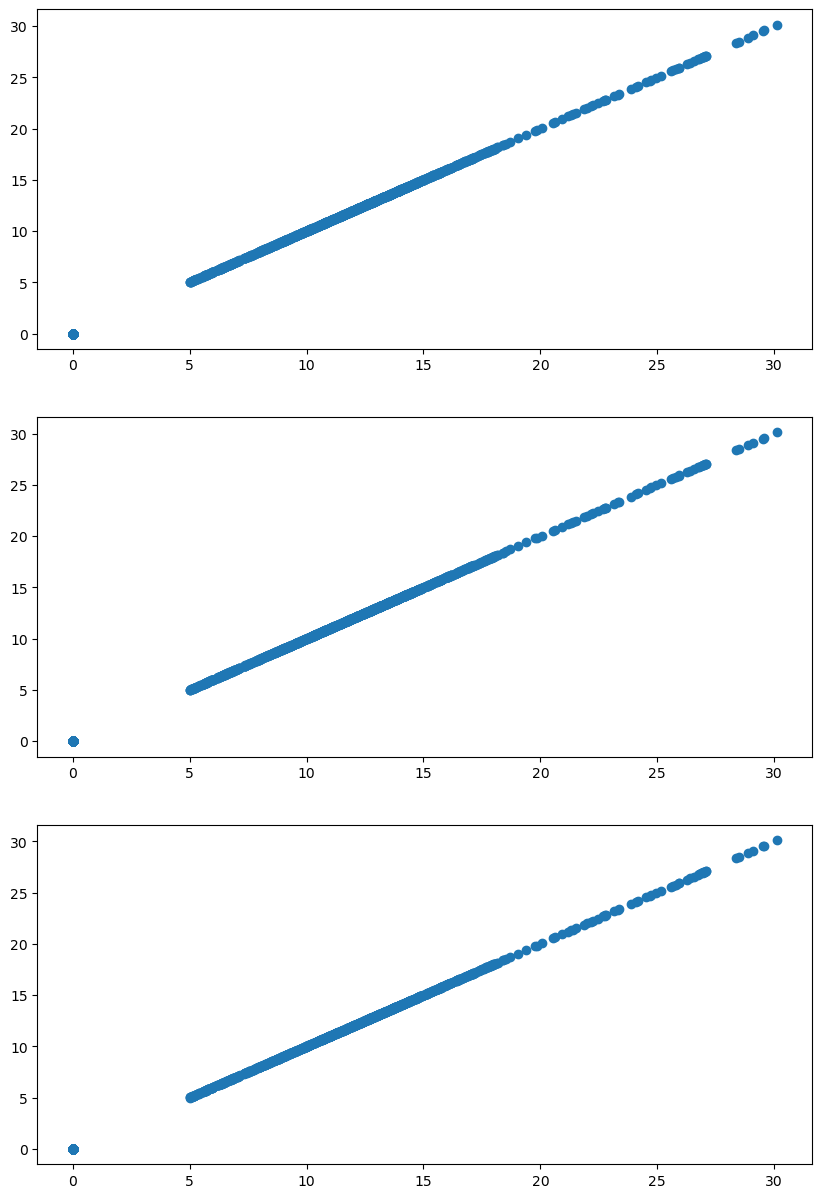

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 15))
ax[0].scatter(yo1,yo1)
ax[1].scatter(yo2,yo2)
ax[2].scatter(yo3,yo1)

True True True


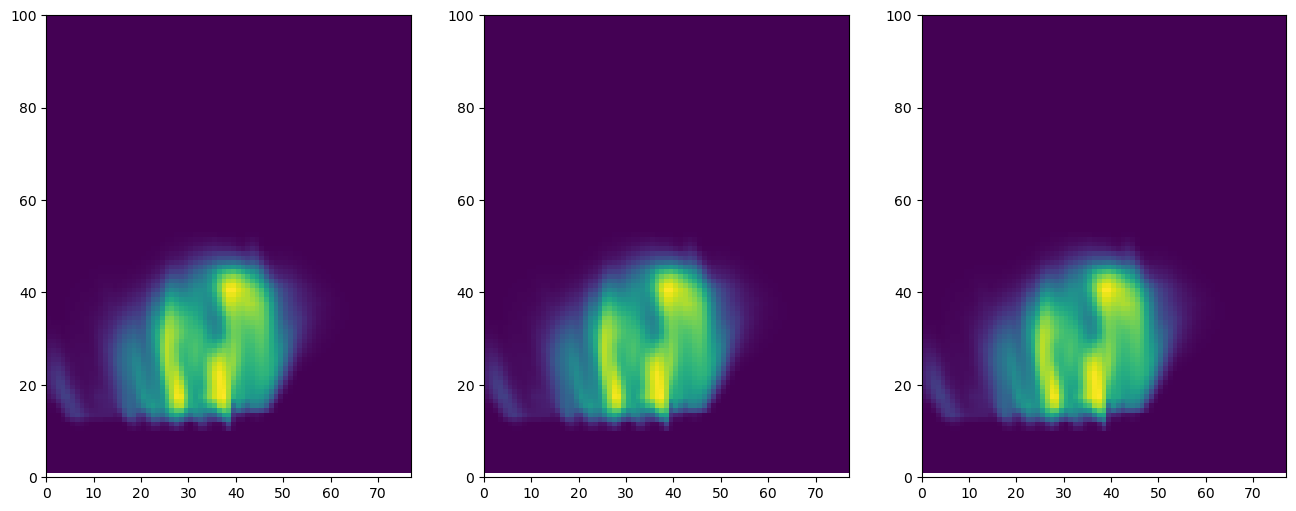

In [15]:
truth1 = data1['truth'][:]
truth2 = data2['truth'][:]
truth3 = data3['truth'][:]
print(np.isnan(truth1).any(), np.isnan(truth2).any(), np.isnan(truth3).any())
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].pcolormesh(truth1[:,0,:,0].T)
ax[1].pcolormesh(truth2[:,0,:,0].T)
ax[2].pcolormesh(truth3[:,0,:,0].T)
plt.show()

In [16]:
truth1[:,0,:,0].T

array([[nan, nan, nan, ..., nan, nan, nan],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

/tmp/ipykernel_397760/1383221275.py:43: RuntimeWarning: Mean of empty slice
  mean_xa = np.nanmean(xa, axis=2)
/tmp/ipykernel_397760/1383221275.py:44: RuntimeWarning: Mean of empty slice
  mean_xf = np.nanmean(xf, axis=2)
/tmp/ipykernel_397760/1383221275.py:76: RuntimeWarning: Mean of empty slice
  mean_xa = np.nanmean(xa, axis=2)
/tmp/ipykernel_397760/1383221275.py:77: RuntimeWarning: Mean of empty slice
  mean_xf = np.nanmean(xf, axis=2)


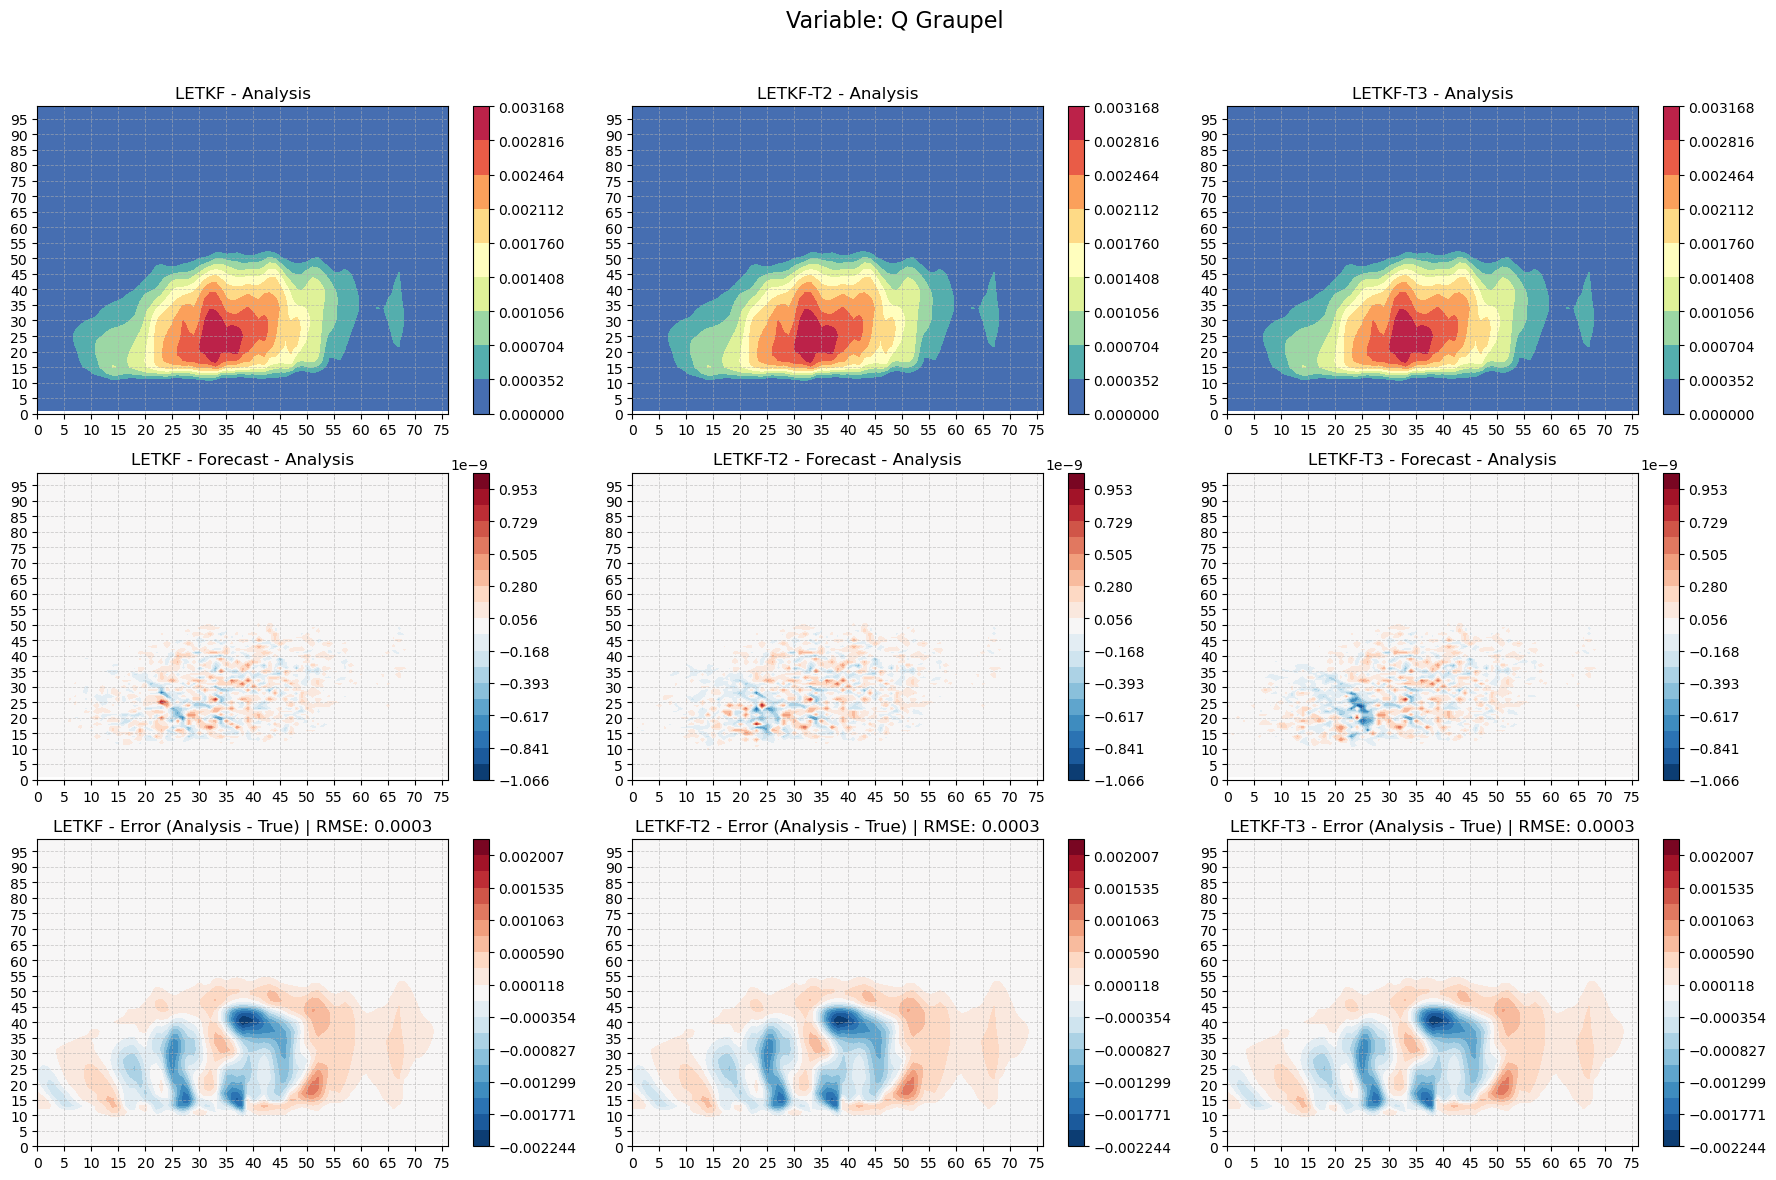

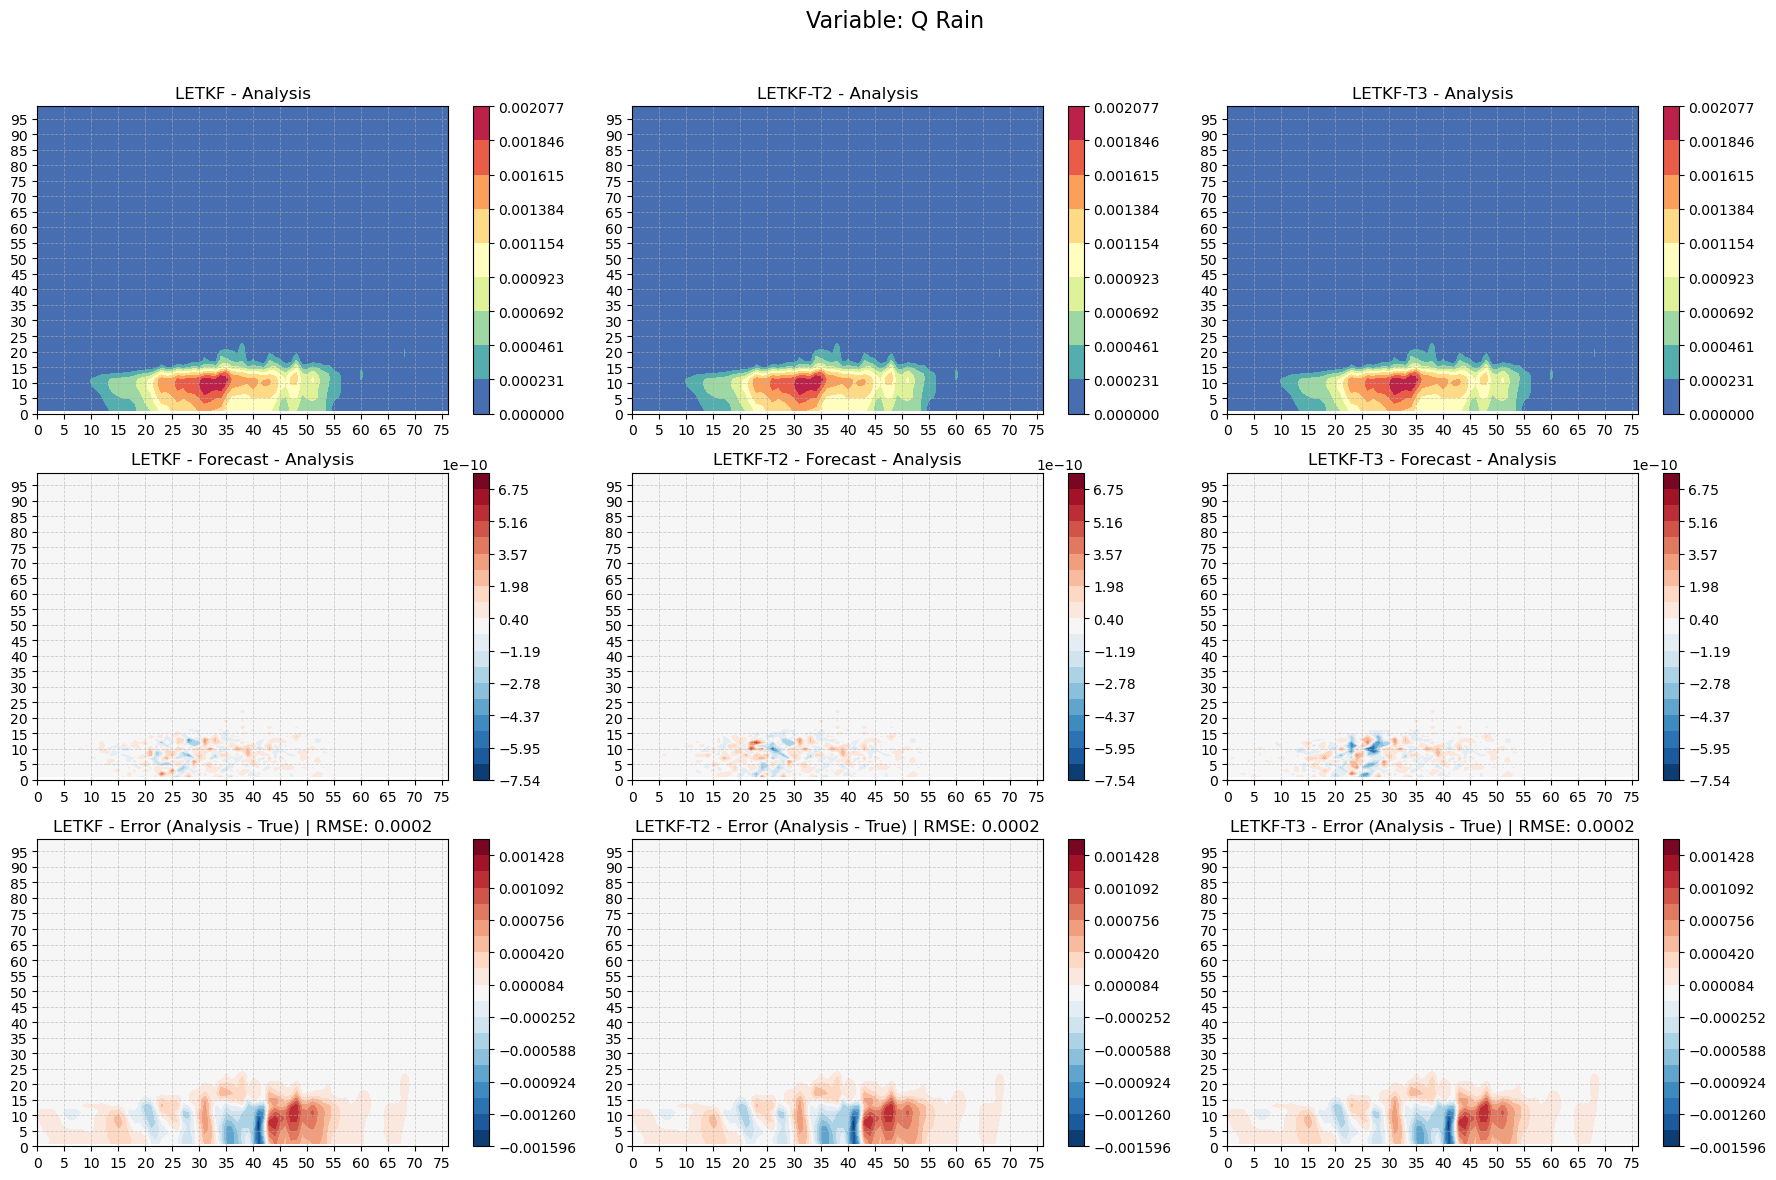

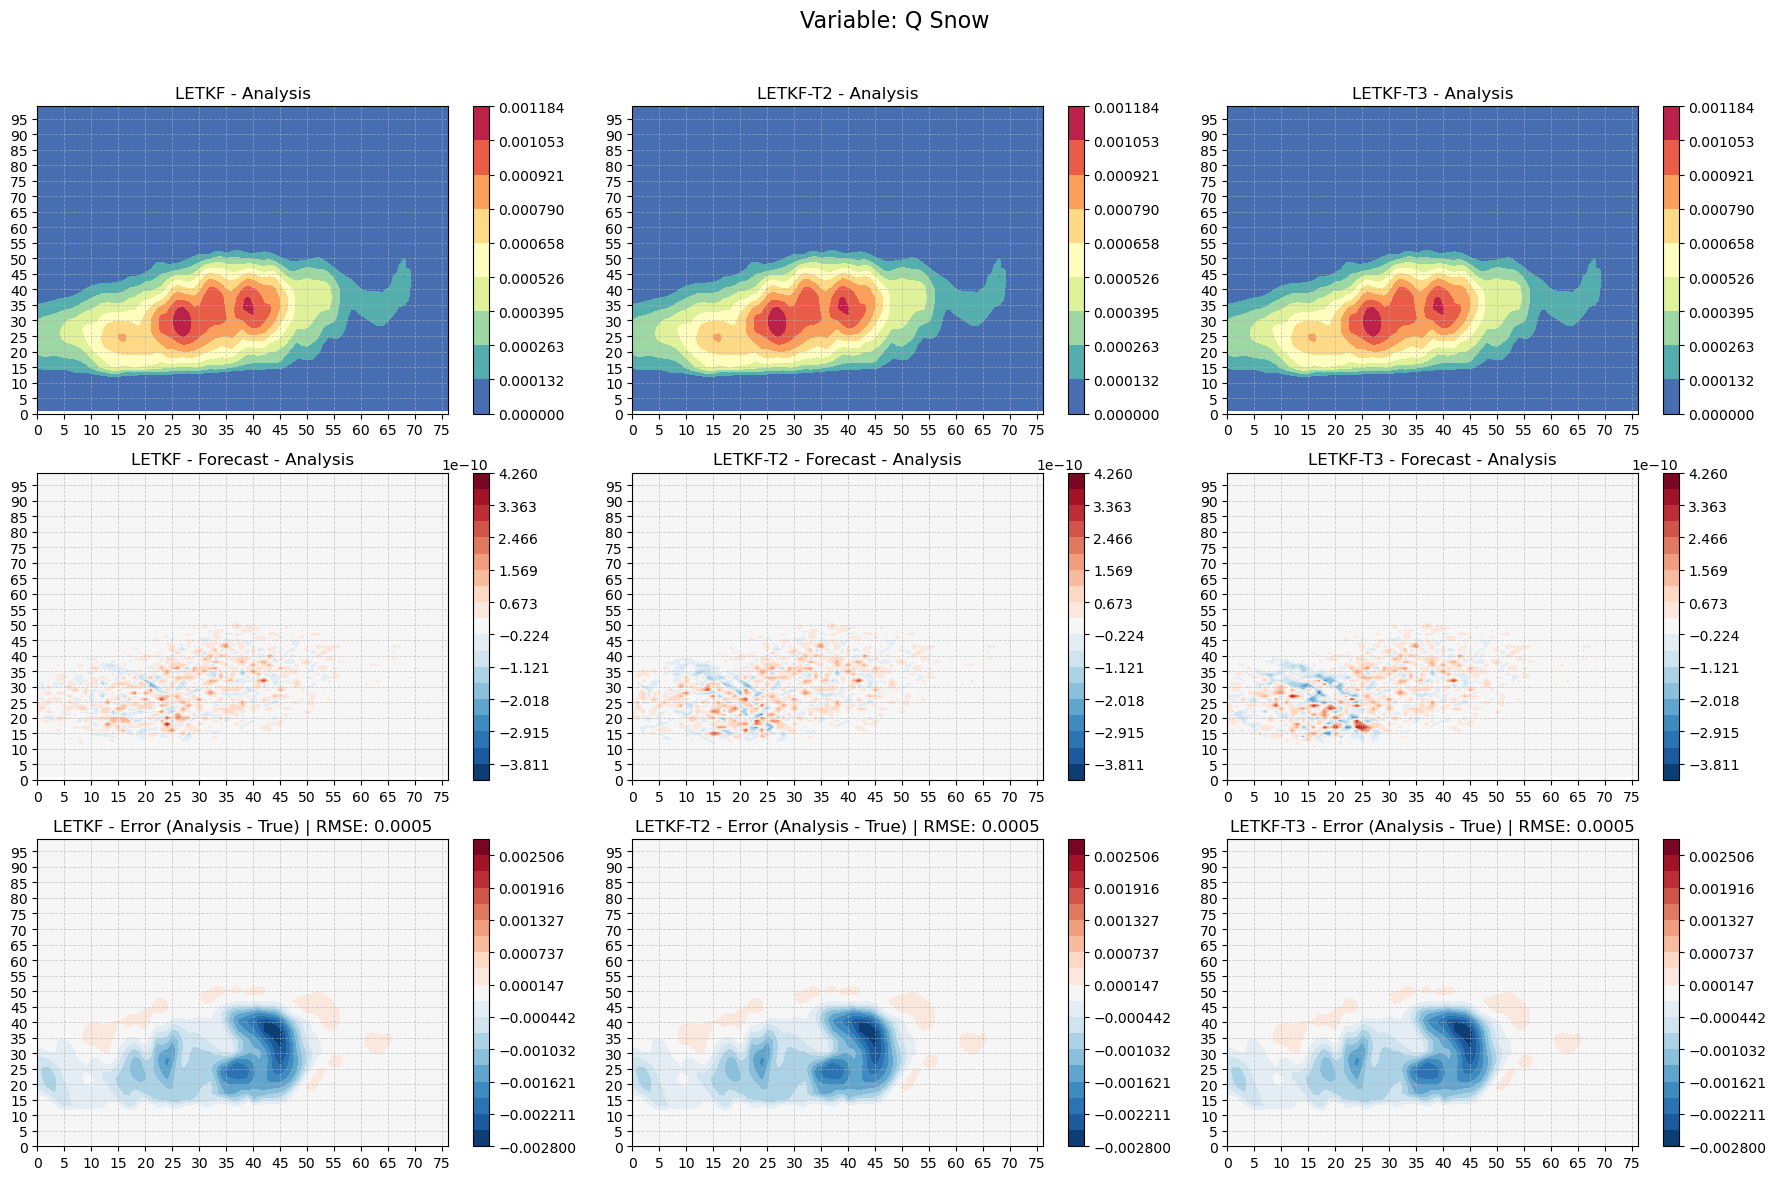

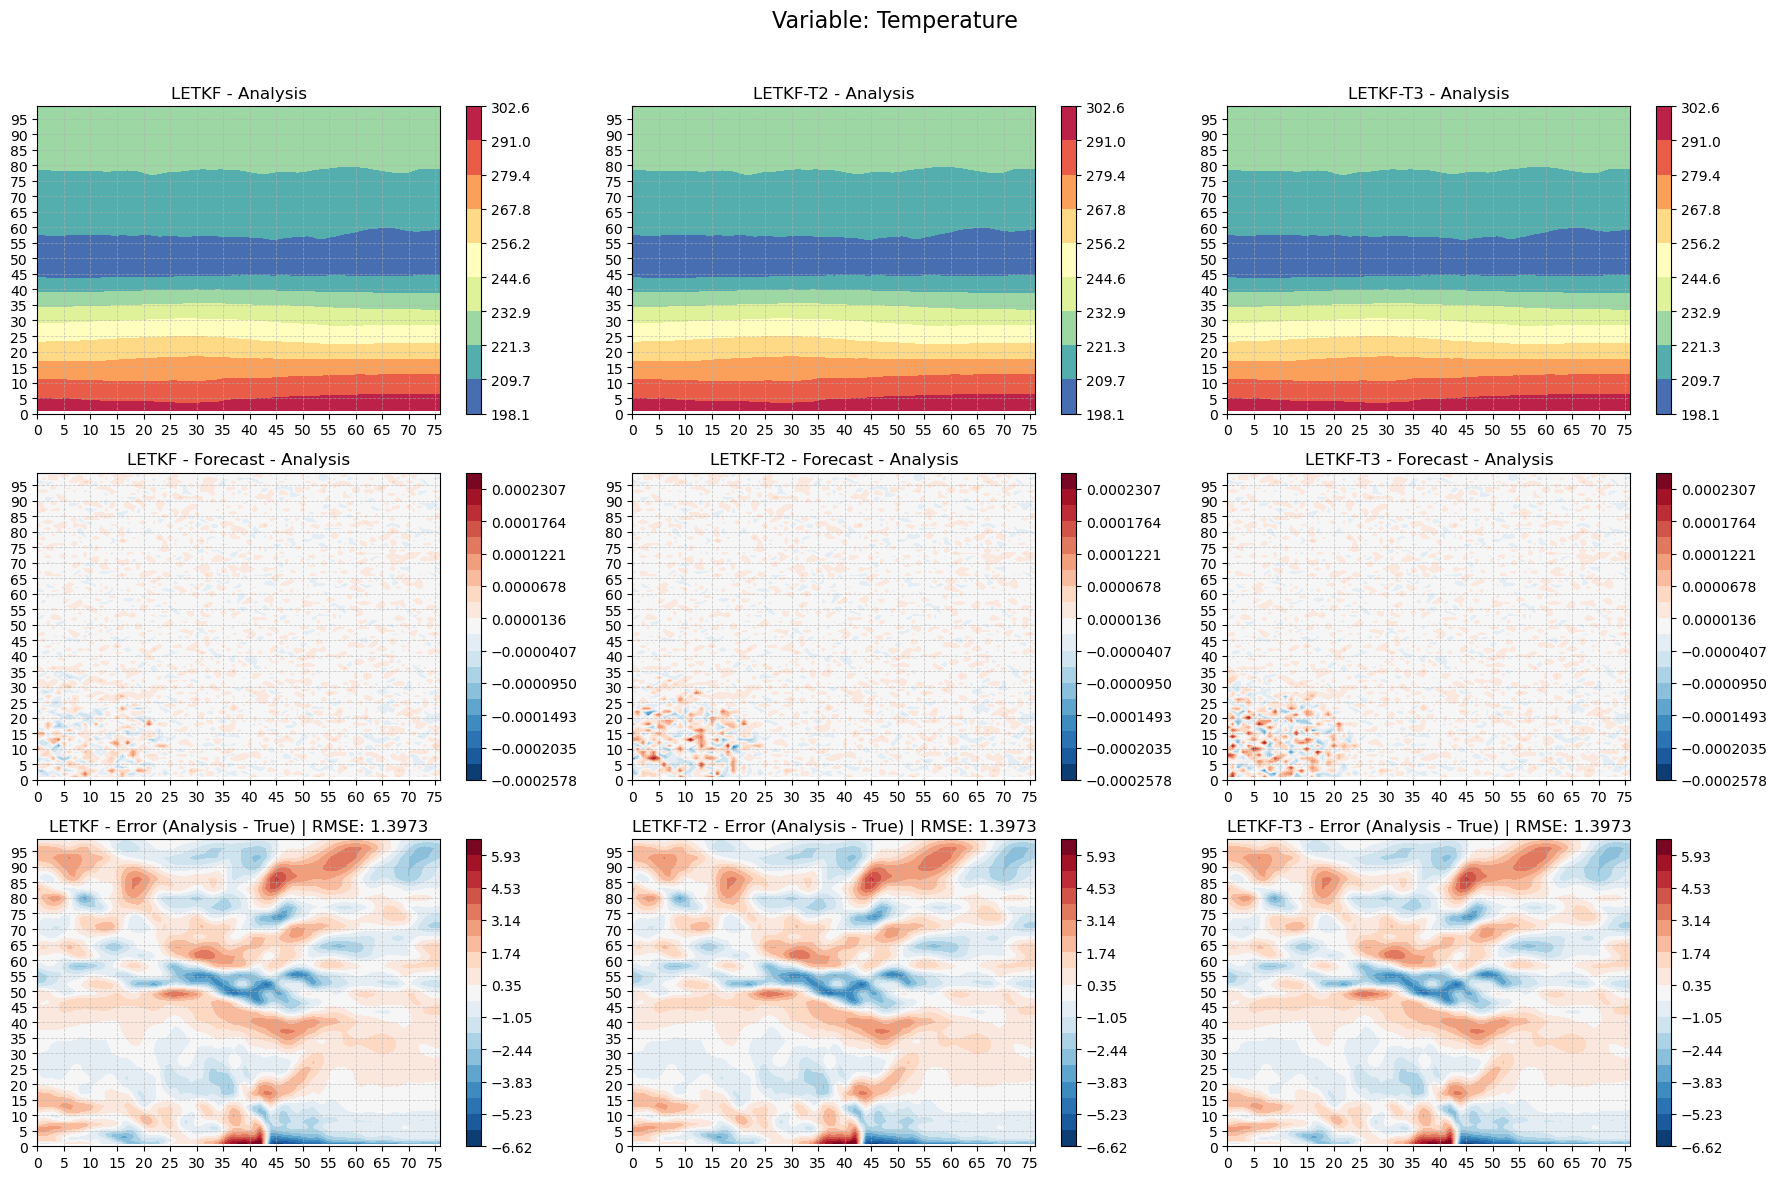

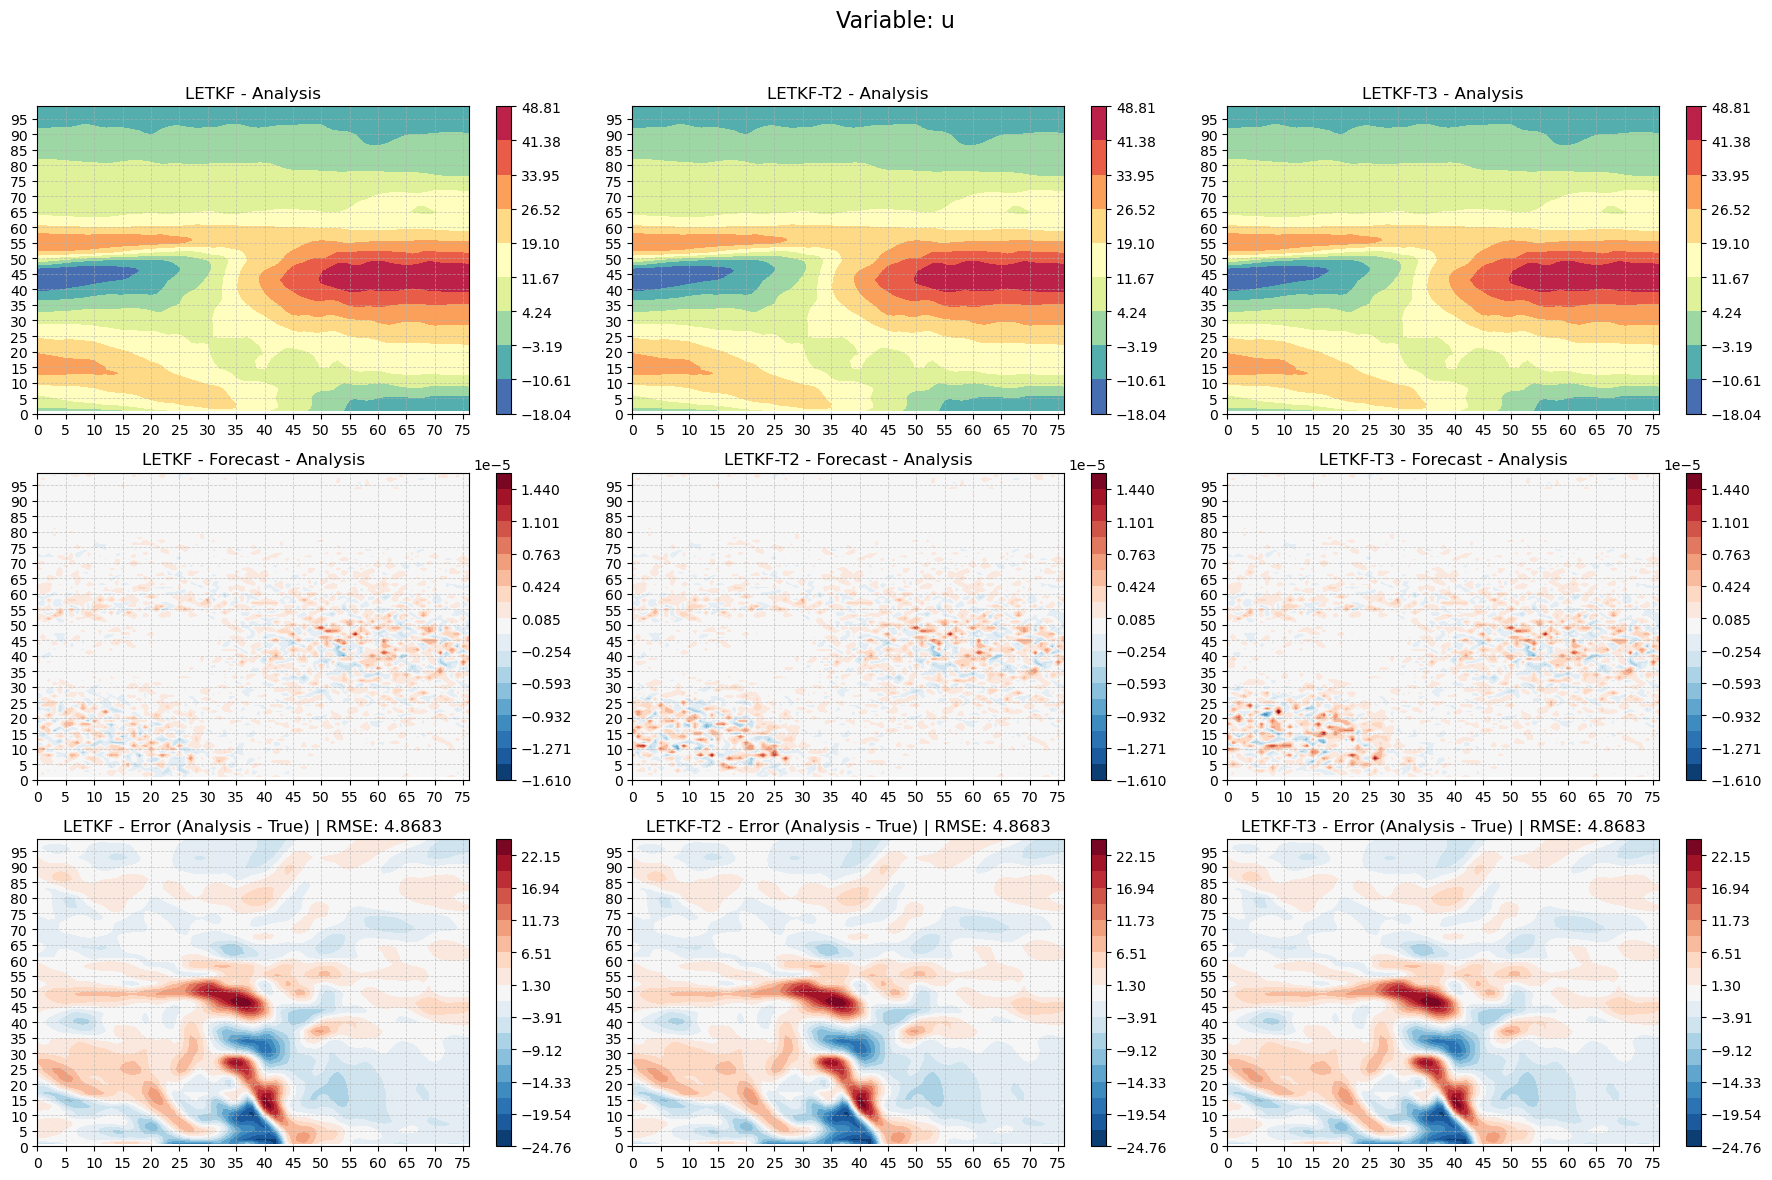

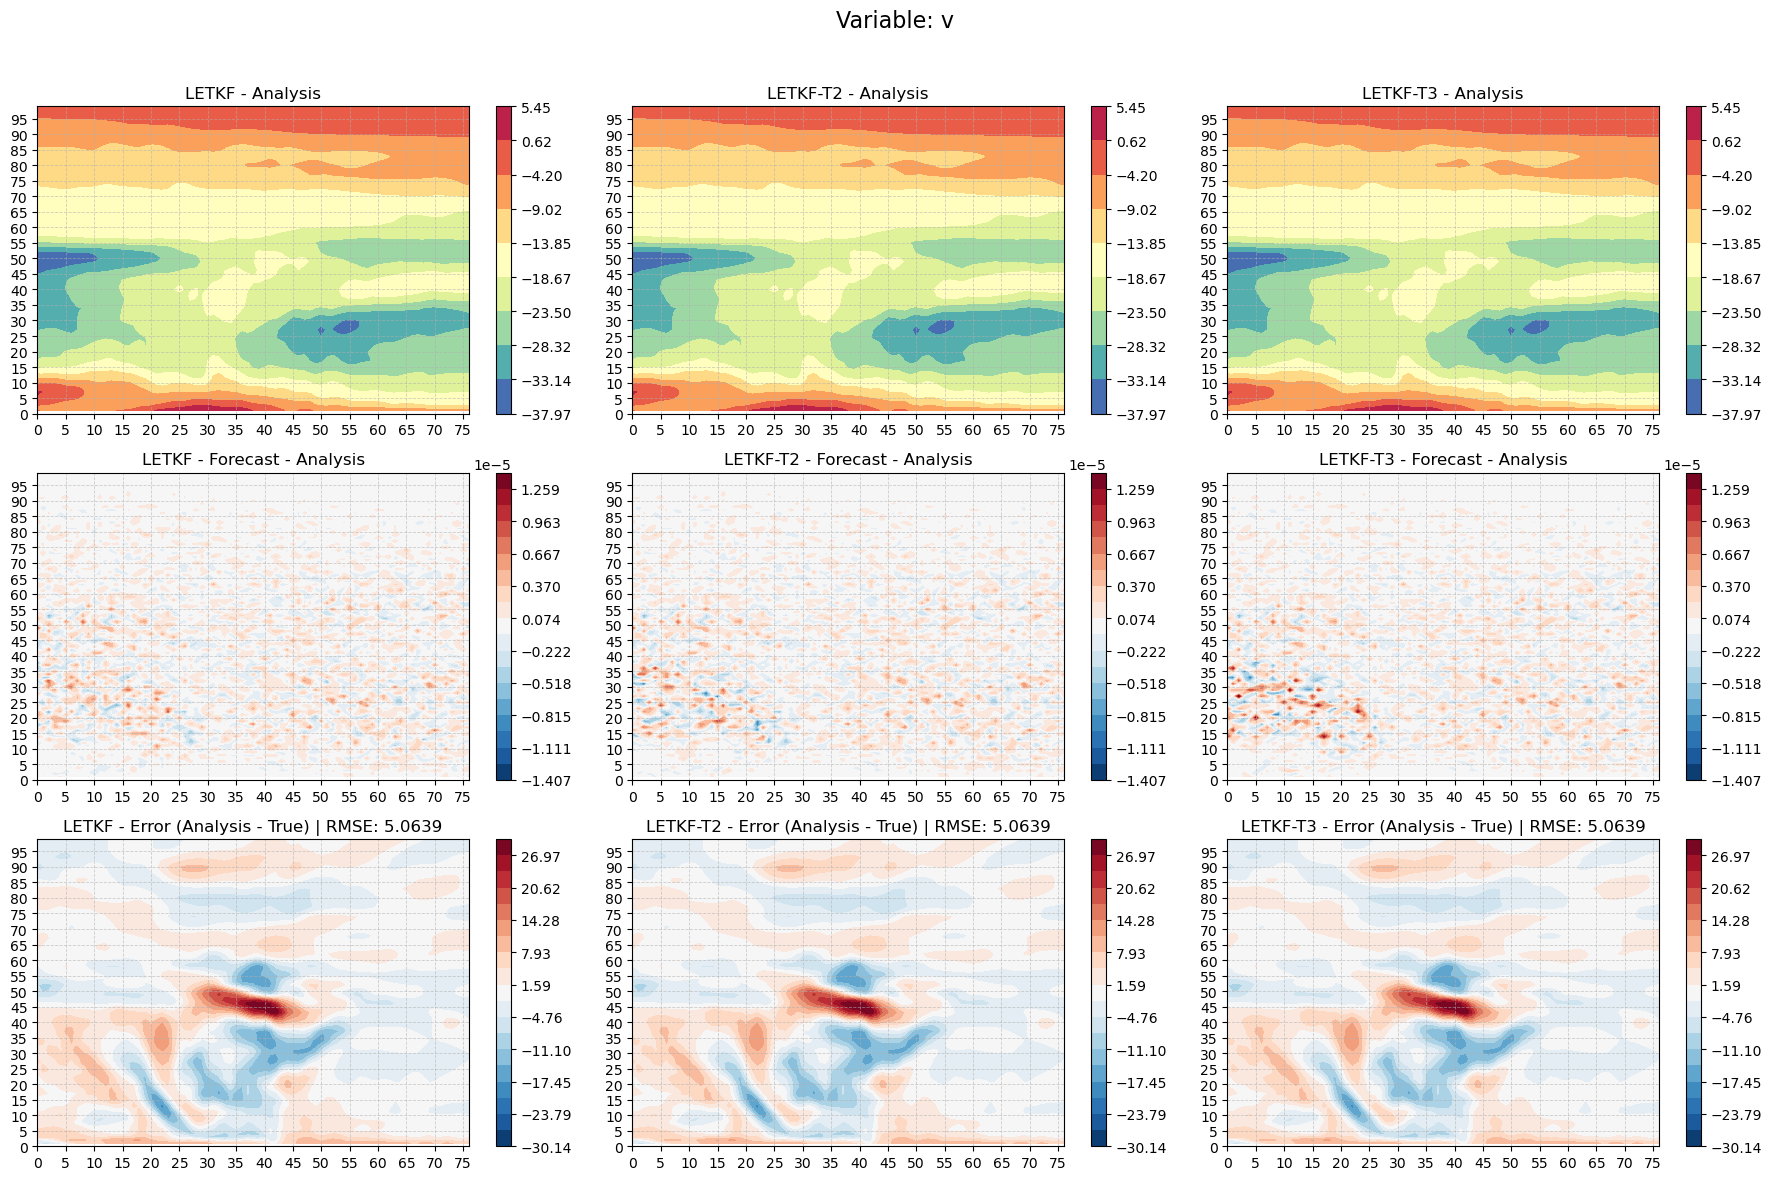

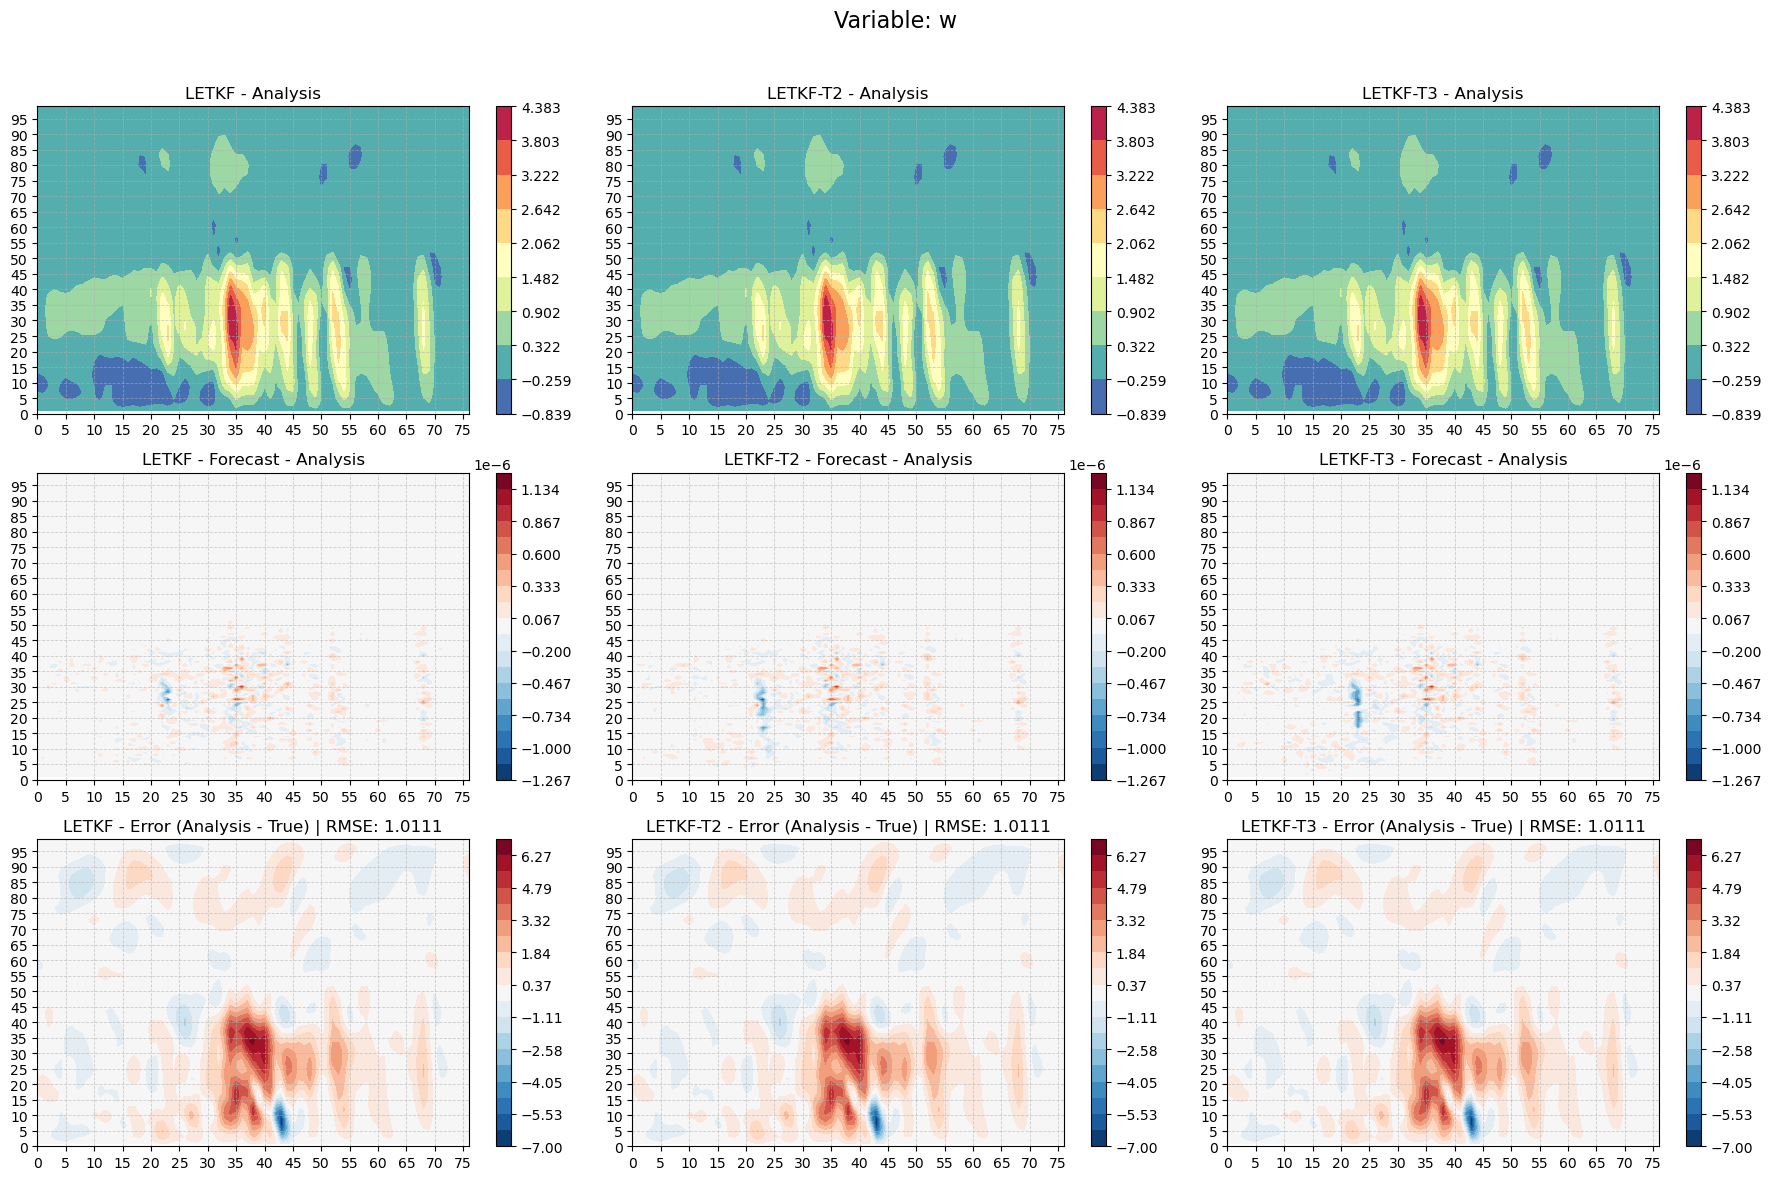

In [17]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosdemerzel/wrf_python_Assimilation/data/runs/full2d_multicycle/"

# Define file paths
file_paths = {
    'LETKF'   : f'{path}Multicycle_v1_2023-12-16_19:00:00_temp1_alpha2_kindFULL_2D.npz',
    'LETKF-T2': f'{path}Multicycle_v1_2023-12-16_19:00:00_temp2_alpha2_kindFULL_2D.npz',
    'LETKF-T3': f'{path}Multicycle_v1_2023-12-16_19:00:00_temp3_alpha2_kindFULL_2D.npz'
}

# Variable names
variables = {
    0: 'Q Graupel',
    1: 'Q Rain',
    2: 'Q Snow',
    3: 'Temperature',
    5: 'u',
    6: 'v',
    7: 'w'
}

r_loc = 5  # Localization radius

for var_index, var_name in variables.items():
    ncols = len(file_paths)
    fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12))

    contour_levels = {}  # Store contour levels and ticks per row
    vmin_fields = []
    vmax_fields = []
    diff_maxs = []
    err_maxs = []

    for col_index, (col_name, file_path) in enumerate(file_paths.items()):
        data = np.load(file_path)

        xa = data['xa'][:, 0, :, :, :]
        xf = data['xf'][:, 0, :, :, :]
        true_state = data['truth'][:, 0, :, :]

        mean_xa = np.nanmean(xa, axis=2)
        mean_xf = np.nanmean(xf, axis=2)

        forecast_field = mean_xf[:, :, var_index]
        analysis_field = mean_xa[:, :, var_index]
        true_field = true_state[:, :, var_index]

        diff_forecast_analysis = forecast_field - analysis_field
        error_analysis = analysis_field - true_field

        vmin_fields.append(np.nanmin(analysis_field))
        vmax_fields.append(np.nanmax(analysis_field))
        diff_maxs.append(np.nanmax(np.abs(diff_forecast_analysis)))
        err_maxs.append(np.nanmax(np.abs(error_analysis)))


    vmin_field=np.nanmin(vmin_fields)
    vmax_field=np.nanmax(vmax_fields)
    contour_levels['field'] = np.linspace(vmin_field, vmax_field, 10)

    diff_max = np.nanmax(diff_maxs)
    contour_levels['diff'] = np.linspace(-diff_max, diff_max, 20)

    err_max = np.nanmax(err_maxs)
    contour_levels['error'] = np.linspace(-err_max, err_max, 20)

    for col_index, (col_name, file_path) in enumerate(file_paths.items()):
        data = np.load(file_path)

        xa = data['xa'][:, 0, :, :, :]
        xf = data['xf'][:, 0, :, :, :]
        true_state = data['truth'][:, 0, :, :]

        mean_xa = np.nanmean(xa, axis=2)
        mean_xf = np.nanmean(xf, axis=2)

        forecast_field = mean_xf[:, :, var_index]
        analysis_field = mean_xa[:, :, var_index]
        true_field = true_state[:, :, var_index]

        diff_forecast_analysis = analysis_field - forecast_field
        error_analysis = analysis_field - true_field

        # Forecast
        im0 = axs[0, col_index].contourf(analysis_field.T, cmap='Spectral_r', levels=contour_levels['field'])
        cb0 = fig.colorbar(im0, ax=axs[0, col_index])
        axs[0, col_index].set_title(f"{col_name} - Analysis")

        # Forecast - Analysis Difference
        im1 = axs[1, col_index].contourf(diff_forecast_analysis.T, cmap='RdBu_r', levels=contour_levels['diff'])
        cb1 = fig.colorbar(im1, ax=axs[1, col_index])
        axs[1, col_index].set_title(f"{col_name} - Forecast - Analysis")

        # Compute RMSE inside the square
        rmse = np.sqrt(np.nanmean(error_analysis**2))

        # Analysis Error
        im2 = axs[2, col_index].contourf(error_analysis.T, cmap='RdBu_r', levels=contour_levels['error'])
        cb2 = fig.colorbar(im2, ax=axs[2, col_index])
        axs[2, col_index].set_title(f"{col_name} - Error (Analysis - True) | RMSE: {rmse:.4f}")

        # Grid every 2 units and add square
        for ax in axs[:, col_index]:
            ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
            ax.set_xticks(np.arange(0, forecast_field.shape[0], 5))
            ax.set_yticks(np.arange(0, forecast_field.shape[1], 5))

    # General title
    fig.suptitle(f"Variable: {var_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()